# DESAFIO

Para garantir uma maior eficiência no monitoramento de trânsito, os agentes de uma empresa utilizam um sistema automático de detecção e reconhecimento de placas automotivas, porém o sistema utilizado é muito antigo e apresenta inconsistências, logo precisa ser substituído. Como desafio de Computação Cognitiva, sua tarefa é implementar um novo sistema que reconhece os caracteres da placa dos carros.

Para isso utilize o dataset [Car License Plate Detection](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection).

Você pode utilizar um algoritmo/biblioteca de OCR (Optical Character Recognition) para fazer a leitura dos caracteres.

O código deve ser bem documentado e modularizado, e o github do projeto deverá ser enviado.

## Estrutura do Projeto

**Fase 1: Engenharia de Dados**

1.1. Coleta de imagens do repositório do Kaggle.  
1.2. Conversão dos dados de Pascal VOC (XML format) para YOLO (TXT format).  
1.3. Dividir o conjunto de dados em treino e teste e salvar em pastas de acordo com a estrutura do YOLO.  

**Fase 2: Treinamento e Validação do YOLO (Detecção)**

2.1. Treinar o modelo YOLO para identificar placas automotivas.  
2.2. Validar o modelo treinado utilizando métricas de desempenho (ex: mAP, precisão, recall).  
2.3. Salvar o melhor modelo `best.pt` para que possa ser utilizado posteriormente.  

**Fase 3: Desenvolvimento do Pipeline de OCR (OpenCV + EasyOCR/PyTesseract)**

3.1. Usar modelo treinado para identificar placas  
3.2. Usar OCR para extrair texto SOMENTE da região delimitada como placa.  

**Fase 4: Documentação do Repositório**

4.1. Documentar o código e criar um README.md com instruções de uso.  

A partir de agora, vamos detalhar cada uma das etapas do desafio.

In [20]:
#Importando as bibliotecas relevantes para o trabalho
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import cv2
import urllib.request
import glob
import xml.etree.ElementTree as ET
import shutil
from sklearn.model_selection import train_test_split
import yaml # Usado para criar o arquivo Yml, necessário para o treinamento com Yolo
import easyocr
from ultralytics import YOLO
from IPython.display import Image, display
%matplotlib inline

## 1. Engenharia de Dados

### 1.1 Coletar imagens

- Baixar o dataset [Car License Plate Detection](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection)
- Extrair as imagens e os arquivos de anotação.

In [ ]:
url = "https://www.kaggle.com/api/v1/datasets/download/andrewmvd/car-plate-detection" # Endereço dos arquivos
nome_arquivo = "car-plate-detection.zip" # Nome do arquivo .zip
pasta_destino = './car-plate-detection' #Pasta para onde serão extraídos os arquivos


# Download do dataset em .zip
print('Download em andamento...')
urllib.request.urlretrieve(url, nome_arquivo)
print("Download concluído!")

# Extraindo o arquivo zipado na pasta_destino
with zipfile.ZipFile(nome_arquivo, 'r') as zip_ref:
  zip_ref.extractall(pasta_destino)

print(f'Conjunto de dados extraído para {pasta_destino}')

# Deletando o arquivo .zip
os.remove(nome_arquivo)
print(f'O arquivo {nome_arquivo} foi excluído com sucesso!')

### 1.2 Conversão e Divisão do Dados (2, 3 e 4)

O conjunto de dados foi fornecido com os arquivos no formato Pascal VOC (XML). Contudo, para usar treinar um modelo de detecção de placas de carro com Yolo, é necessário converter os arquivos do formato Pascal VOC (XML) para o formato YOLO (TXT).

O modelo Pascal VOC (XML) utiliza os valores absolutos das coordenadas da caixa delimitadora (bounding box),  enquanto o modelo YOLO (TXT) utiliza valores relativos. Portanto, é necessário fazer a conversão dos valores absolutos para valores relativos.
<center>
<figure>
  <img src="doc\Dif_pascal_yolo.png" width="50%" alt="Diferença entre Pascal VOC e YOLO">
  <figcaption>Tabela indicando parâmetros de bounding box em diferentes formatos. Disponível em: <a href="https://dragoneye.ai/blog/a-guide-to-bounding-box-formats/" target="_blank" rel="noopener">dragoneye</a> </figcaption>
</figure>
</center>


Além disso, o Yolo exige uma estrutura de pasta bem específica (mostrada abaixo), por isso, é necessário dividir o conjunto de dados em treino e teste colocando-os nas pastas correspondentes.


```sh
seu_dataset/
│
├── data.yaml              # Arquivo de configuração do dataset
│
├── images/                # Pasta contendo todas as imagens
│   ├── train/             # Imagens para treino
│   ├── val/               # Imagens para validação
│   └── test/              # Imagens para teste (opcional)
│
└── labels/                # Pasta contendo os arquivos de anotação (.txt)
    ├── train/             # Rótulos das imagens de treino
    ├── val/               # Rótulos das imagens de validação
    └── test/              # Rótulos das imagens de teste (opcional)
```


O arquivo `data.yaml` também é necessário para o treinamento do modelo, pois contém informações sobre o dataset, como o caminho das imagens e labels, número de classes e nomes das classes.

In [ ]:
# Definição dos caminhos dos dados atuais
ORIGEM_IMG = "./car-plate-detection/images"
ORIGEM_XML = "./car-plate-detection/annotations"
DESTINO_BASE = "./yolo_dataset"

########## CRIAÇÃO DAS PASTAS NO FORMATO YOLO ###########################
# Estrutura de pastas exigida pelo YOLO
pastas_yolo = {
    'train_images': os.path.join(DESTINO_BASE, 'images', 'train'),
    'val_images': os.path.join(DESTINO_BASE, 'images', 'val'),
    'train_labels': os.path.join(DESTINO_BASE, 'labels', 'train'),
    'val_labels': os.path.join(DESTINO_BASE, 'labels', 'val')
}

# Criando as pastas de destino de acordo com a estrutura Yolo
for pasta in pastas_yolo.values():
    os.makedirs(pasta, exist_ok=True)
#########################################################################

########## FUNÇÃO DE CONVERSÃO XML (PASCAL VOC) -> TXT (YOLO)  ##########
def converter_xml_para_yolo(xml_path):
    try: #Parsing do arquivo XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Obtém dimensões da imagem
        size = root.find('size')
        w = int(size.find('width').text)
        h = int(size.find('height').text)
        
        yolo_linhas = []
        
        # Itera sobre as tags object para confirmar se a classe se chama license
        for obj in root.iter('object'):
            classe = obj.find('name').text
            if classe != 'licence':
                continue
            
            classe_id = 0  # Classe única, então definimos ID = 0
            
            # Acessa a tag <bndbox> para coletar os valores das coordenadas (xmin,ymin) e (xmax,ymax) do formato PASCAL VOC
            box = obj.find('bndbox')
            xmin = float(box.find('xmin').text)
            ymin = float(box.find('ymin').text)
            xmax = float(box.find('xmax').text)
            ymax = float(box.find('ymax').text)
            
            # Converte as coordenadas de Pascal para Yolo
            x_centro = (xmin + xmax) / 2.0 / w
            y_centro = (ymin + ymax) / 2.0 / h
            largura_box = (xmax - xmin) / w
            altura_box = (ymax - ymin) / h
            
            # Restringe os valores para ficarem estritamente entre 0.0 e 1.0. Exemplo, caso alguns arredondamento
            # resulte em 1.0001 ou -0.0001, o Yolo retorna um erro e descarta a imagem durante o treinamento.
            x_centro = min(max(x_centro, 0.0), 1.0)
            y_centro = min(max(y_centro, 0.0), 1.0)
            largura_box = min(max(largura_box, 0.0), 1.0)
            altura_box = min(max(altura_box, 0.0), 1.0)
            
            # Cria as linhas para serem salvas no padrão Yolo e salva na lista yolo_linhas
            yolo_linhas.append(f"{classe_id} {x_centro:.6f} {y_centro:.6f} {largura_box:.6f} {altura_box:.6f}")
            
        return yolo_linhas # Retorna uma lista de linhas no formato Yolo
    except Exception as e:
        print(f"Erro ao ler {xml_path}: {e}")
        return None
#########################################################################

########## MAPEAMENTO DOS PARES XML E IMAGENS EXISTENTES ################
# Coleta os caminhos de todos os arquivos da pasta car-plate-detection/annotations/ que contém a extensão .xml
arquivos_xml = sorted(glob.glob(os.path.join(ORIGEM_XML, "*.xml")))
pares_validos = []

#Extrai o nome do arquivo e gera o nome base da figura correspondente. Por exemplo:
#a partir do caminho car-plate-detection/annotations/Cars132.xml é  gerado o caminho da imagem
#correspondente como car-plate-detection/images/Cars132.png. Se este caminho existir, adiciono o par de caminhos
#à lista de pares validos. Ex: (car-plate-detection/annotations/Cars132.xml,car-plate-detection/images/Cars132.png).
#Por fim, imprimo o total de pares válidos para que possam conferir com o numero total de registros. 
for xml_path in arquivos_xml:
    nome_base = os.path.splitext(os.path.basename(xml_path))[0]
    caminho_img = os.path.join(ORIGEM_IMG, f"{nome_base}.png")
    
    if os.path.exists(caminho_img):
        pares_validos.append((caminho_img, xml_path))

print(f"Total de amostras identificadas: {len(pares_validos)}")
#########################################################################

########## DIVISAO DO CONJUNTO EM TREINO (80%) E VALIDAÇÃO (20%) ########
treino_pares, val_pares = train_test_split(
    pares_validos, 
    train_size=0.8, 
    random_state=42
)
#########################################################################

########## FUNÇÃO PARA COPIAR AS IMAGENS PARA AS PASTAS CORRETAS E SALVAR OS ARQUIVOS TXT ################
def copiar_e_salvar(pares, split_nome):
    """
    Copia as imagens da pasta original para as pastas \images\train e \images\val. Cria os arquivos .txt correspondentes
    nas pastas \label\\train e \label\val.
    pares: lista de tuplas contendo os pares (caminho-imagem, caminho-xml). Gerada a partir do train_test_split acima
    split_nome: nome da pasta de destino que está sendo criada 'train','val' ou 'test'.
    """
    #Retorna o caminho das imagens de destino, baseado no que foi declarado no dicionário pastas_yolo
    pasta_img_dst = pastas_yolo[f'{split_nome}_images']
    pasta_lbl_dst = pastas_yolo[f'{split_nome}_labels']
    
    # Para cada par de arquivos, copia a imagem para o destino e cria o arquivo .txt com o mesmo nome na pasta labels
    for img_path, xml_path in pares:
        nome_base = os.path.splitext(os.path.basename(xml_path))[0]
        
        # Copia a imagem para o destino
        shutil.copy(img_path, os.path.join(pasta_img_dst, f"{nome_base}.png"))
        
        # Converte o XML correspondente e grava o TXT
        linhas_yolo = converter_xml_para_yolo(xml_path)
        if linhas_yolo:
            with open(os.path.join(pasta_lbl_dst, f"{nome_base}.txt"), 'w') as f:
                f.write('\n'.join(linhas_yolo))
#########################################################################

# Executa a distribuição
copiar_e_salvar(treino_pares, 'train')
copiar_e_salvar(val_pares, 'val')

print(f"Dados processados com sucesso!")
print(f"Treino: {len(treino_pares)} imagens em {pastas_yolo['train_images']}")
print(f"Validação: {len(val_pares)} imagens em {pastas_yolo['val_images']}")

print("Criando o arquivo data.yaml...")

Total de amostras identificadas: 433
Dados processados com sucesso!
Treino: 346 imagens em ./yolo_dataset\images\train
Validação: 87 imagens em ./yolo_dataset\images\val
Criando o arquivo data.yaml...


Salvando o arquivo `data.yml` com as informações do dataset, como o caminho das imagens e labels, número de classes e nomes das classes.

In [ ]:
### CONFIGURANDO ARQUIVO YAML
# Estrutura do arquivo de configuração para o YOLO
config_yolo = {
    'path': "yolo_dataset", # Caminho relativo para a pasta yolo_dataset, onde estão as imagens e anotações (labels)
    'train': 'images/train', #Caminho para as imagens de treinamento
    'val': 'images/val',
    'names': {
        0: 'licence'
    }
}

# Salvando no arquivo data.yaml
with open('data.yaml', 'w') as f:
    yaml.dump(config_yolo, f, default_flow_style=False)

print("Arquivo data.yaml criado com sucesso!")

Arquivo data.yaml criado com sucesso!


### Visualização dos dados antes do treinamento

train 346 4 4
val 87 4 4


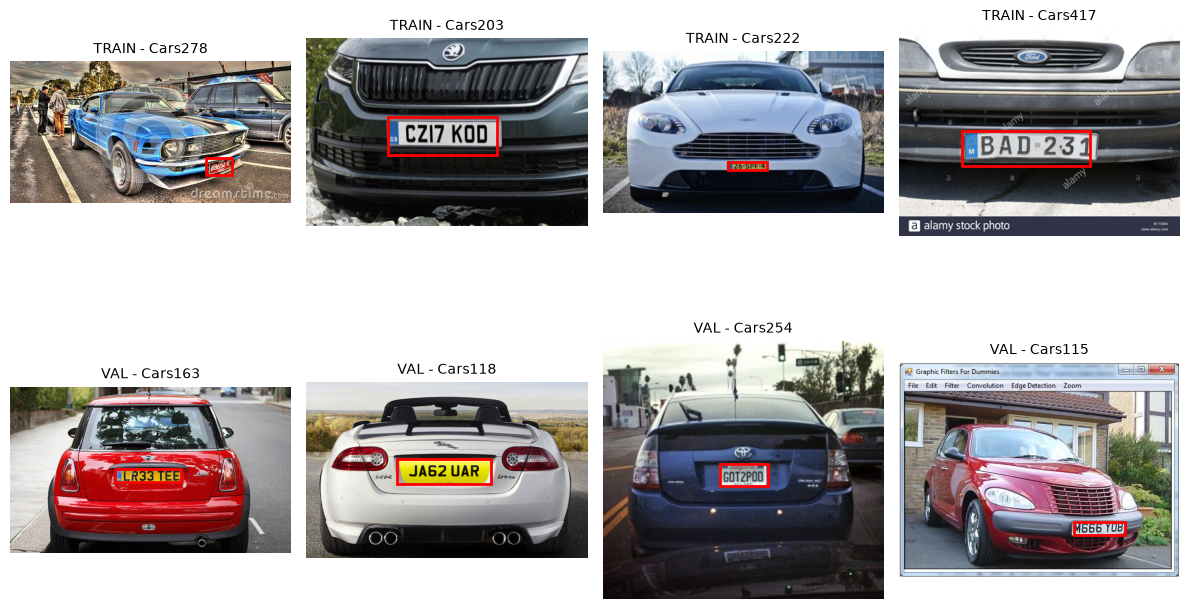

In [19]:
def plotar_amostras_yolo(base_dir, split, num_amostras=2, ax_list=None, start_idx=0):
    """
    Carrega imagens aleatórias e desenha as caixas delimitadoras a partir das anotações do YOLO.
    base_dir: caminho base do diretório com as imagens no padrão yolo_dataset
    split: indica a diretório de imagens desejado ('train', 'val')
    num_amostras: Define o numero de amostras escolhidas
    ax_list: define a posição do subgráfico a ser plotado
    start_idx = índice inicial do gráfico
    """
    img_dir = os.path.join(base_dir, 'images', split) #Constrói os caminhos para a pasta de imagens 
    lbl_dir = os.path.join(base_dir, 'labels', split) #Constrói os caminhos para a pasta de rótulos
    
    imagens = glob.glob(os.path.join(img_dir, "*.png")) # Lista todas as imagens do split correspondente ('train' ou 'val')
    
    if not imagens: #Se não houver imagens, retorna um erro
        print(f"Nenhuma imagem encontrada em {img_dir}")
        return
    
    
    amostras = random.sample(imagens, min(num_amostras, len(imagens))) # Seleciona amostras aleatórias definida pelo num_amostras
    print(split, len(imagens), num_amostras, len(amostras)) # CHECK POINT (DELETAR!)
    
    for i, img_path in enumerate(amostras):
        img = cv2.imread(img_path) # Carrega a imagem
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converte a imagem de BGR para RGB
        h, w, _ = img.shape # Coleta a altura e largura da imagem
        
        ax = ax_list[start_idx + i] # Define os sugbráficos onde serão plotadas as imagens
        ax.imshow(img_rgb) # Plota o gráfico na posição definida acima

        # Para a imagem sendo plotada, encontra o arquivo de marcação correspondente (.txt)
        nome_base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, f"{nome_base}.txt")
             
        ######### Se houver arquivo .txt correspondente, faz a leitura, converte para valores absolutos
        ######### e faz a plotagem do retângulo com plt.Rectangle.
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                linhas = f.readlines()
                
            for linha in linhas:
                valores = linha.strip().split()
                if len(valores) == 5:
                    x_centro = float(valores[1])
                    y_centro = float(valores[2])
                    largura_box = float(valores[3])
                    altura_box = float(valores[4])
                    
                    # Converte coordenadas YOLO (normalizadas) de volta para pixels absolutos
                    xmin = int((x_centro - largura_box / 2) * w)
                    ymin = int((y_centro - altura_box / 2) * h)
                    box_w = int(largura_box * w)
                    box_h = int(altura_box * h)
                    
                    # Cria e adiciona o retângulo usando Matplotlib
                    rect = plt.Rectangle(
                        (xmin, ymin), box_w, box_h, 
                        fill=False, color='red', linewidth=2
                    )
                    ax.add_patch(rect)
                    
        ax.set_title(f"{split.upper()} - {nome_base}", fontsize=10)
        ax.axis('off')

##### DEFINE A APRESENTAÇÃO DAS LINHAS COM TREINO E VALIDAÇÃO ######### 
def apresentar_dataset_yolo(base_dir, num_por_split=2):
    """
    Cria um grid de exibição comparando amostras de Treino e Validação lado a lado.
    base_dir: caminho base do diretório com as imagens no padrão yolo_dataset
    num_por_split: quantidade de imagens escolhidas (representa o numero de colunas do subplot)
    """
    total_plots = num_por_split * 2
    fig, axes = plt.subplots(2, num_por_split, figsize=(12, 8))
    
    # Ajusta o array de subplots caso seja unidimensional
    axes_flat = axes.flatten()
    
    # Plota amostras de treino na linha superior
    plotar_amostras_yolo(
        base_dir=base_dir, 
        split='train', 
        num_amostras=num_por_split, 
        ax_list=axes_flat, 
        start_idx=0
    )
    
    # Plota amostras de validação na linha inferior
    plotar_amostras_yolo(
        base_dir=base_dir, 
        split='val', 
        num_amostras=num_por_split, 
        ax_list=axes_flat, 
        start_idx=num_por_split
    )
    
    plt.tight_layout()
    plt.show()

# Executa a visualização das amostras
apresentar_dataset_yolo(base_dir='yolo_dataset', num_por_split=4)

## Fase 2: Treinamento e validação do modelo Yolo

In [ ]:
# 1. Carrega o modelo pré-treinado (YOLOv8 Nano)
model = YOLO('yolov8n.pt')

# 2. Executa o treinamento
# Ajuste o parâmetro 'epochs' e 'batch' conforme os recursos da sua máquina.
results = model.train(
    data='data.yaml',       # Arquivo de configuração
    epochs=30,              # Número de épocas
    imgsz=640,              # Redimensionamento padrão do YOLO
    batch=16,               # Tamanho do lote (batch size)
    device='cpu',           # Mude para '0' ou 'cuda' se tiver GPU Nvidia instalada
    workers=2,              # Número de subprocessos para carregar dados
    name='yolo_placas'      # Nome da pasta onde os pesos salvos serão guardados
)

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\marcio_constancio\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.102  Python-3.13.7 torch-2.13.0+cpu CPU (12th Gen Intel Core i7-1255U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

### Métricas de desempenho do modelo

--- Evolução do Treinamento ---


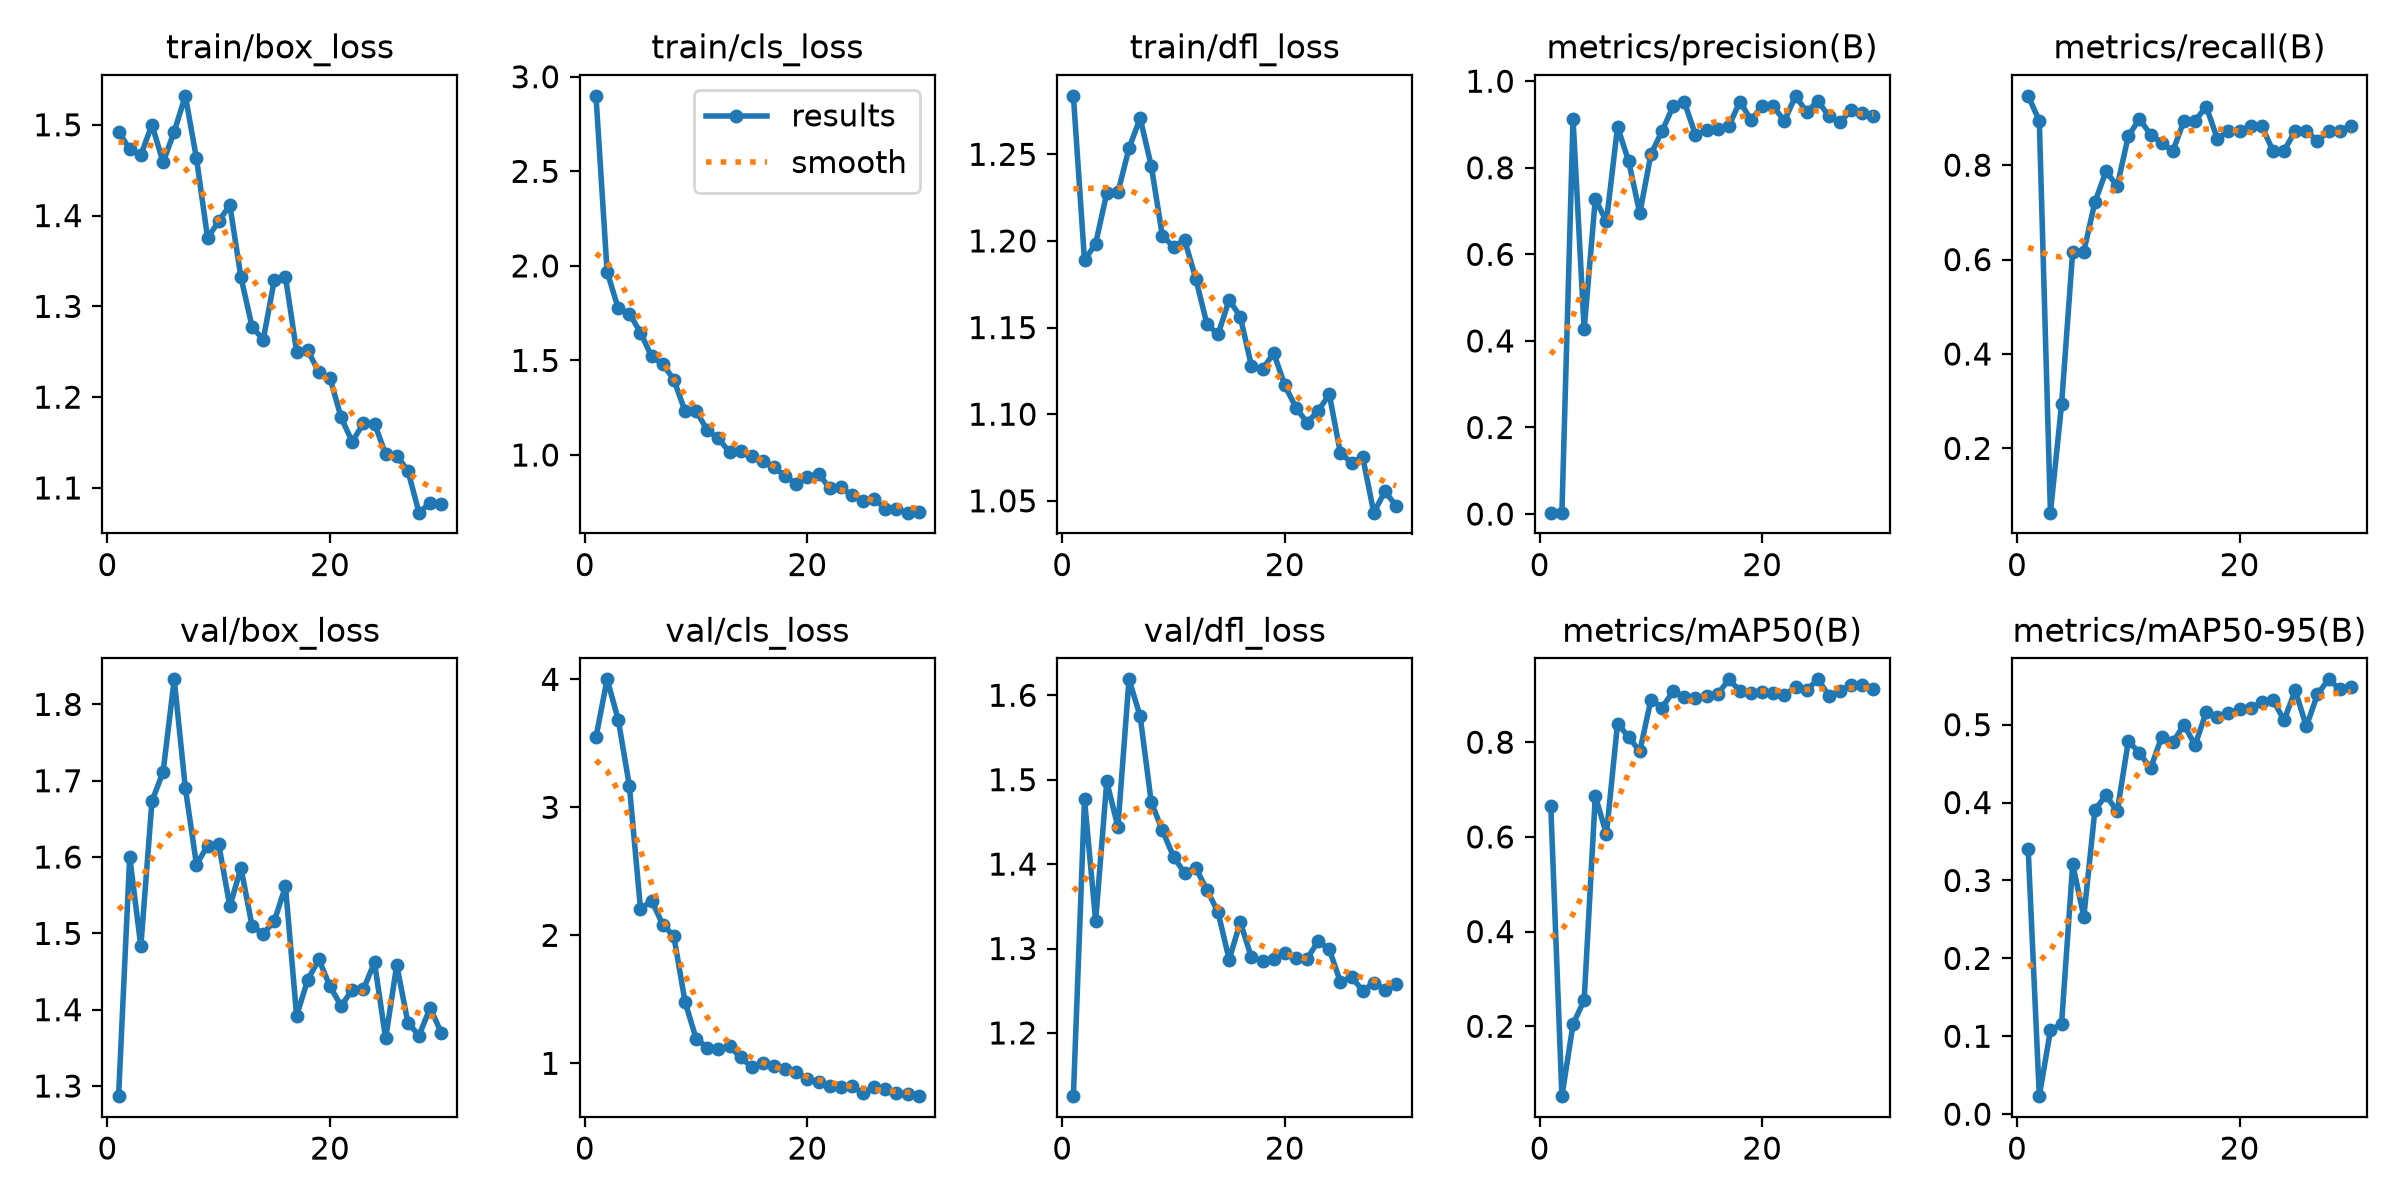


--- Matriz de Confusão ---


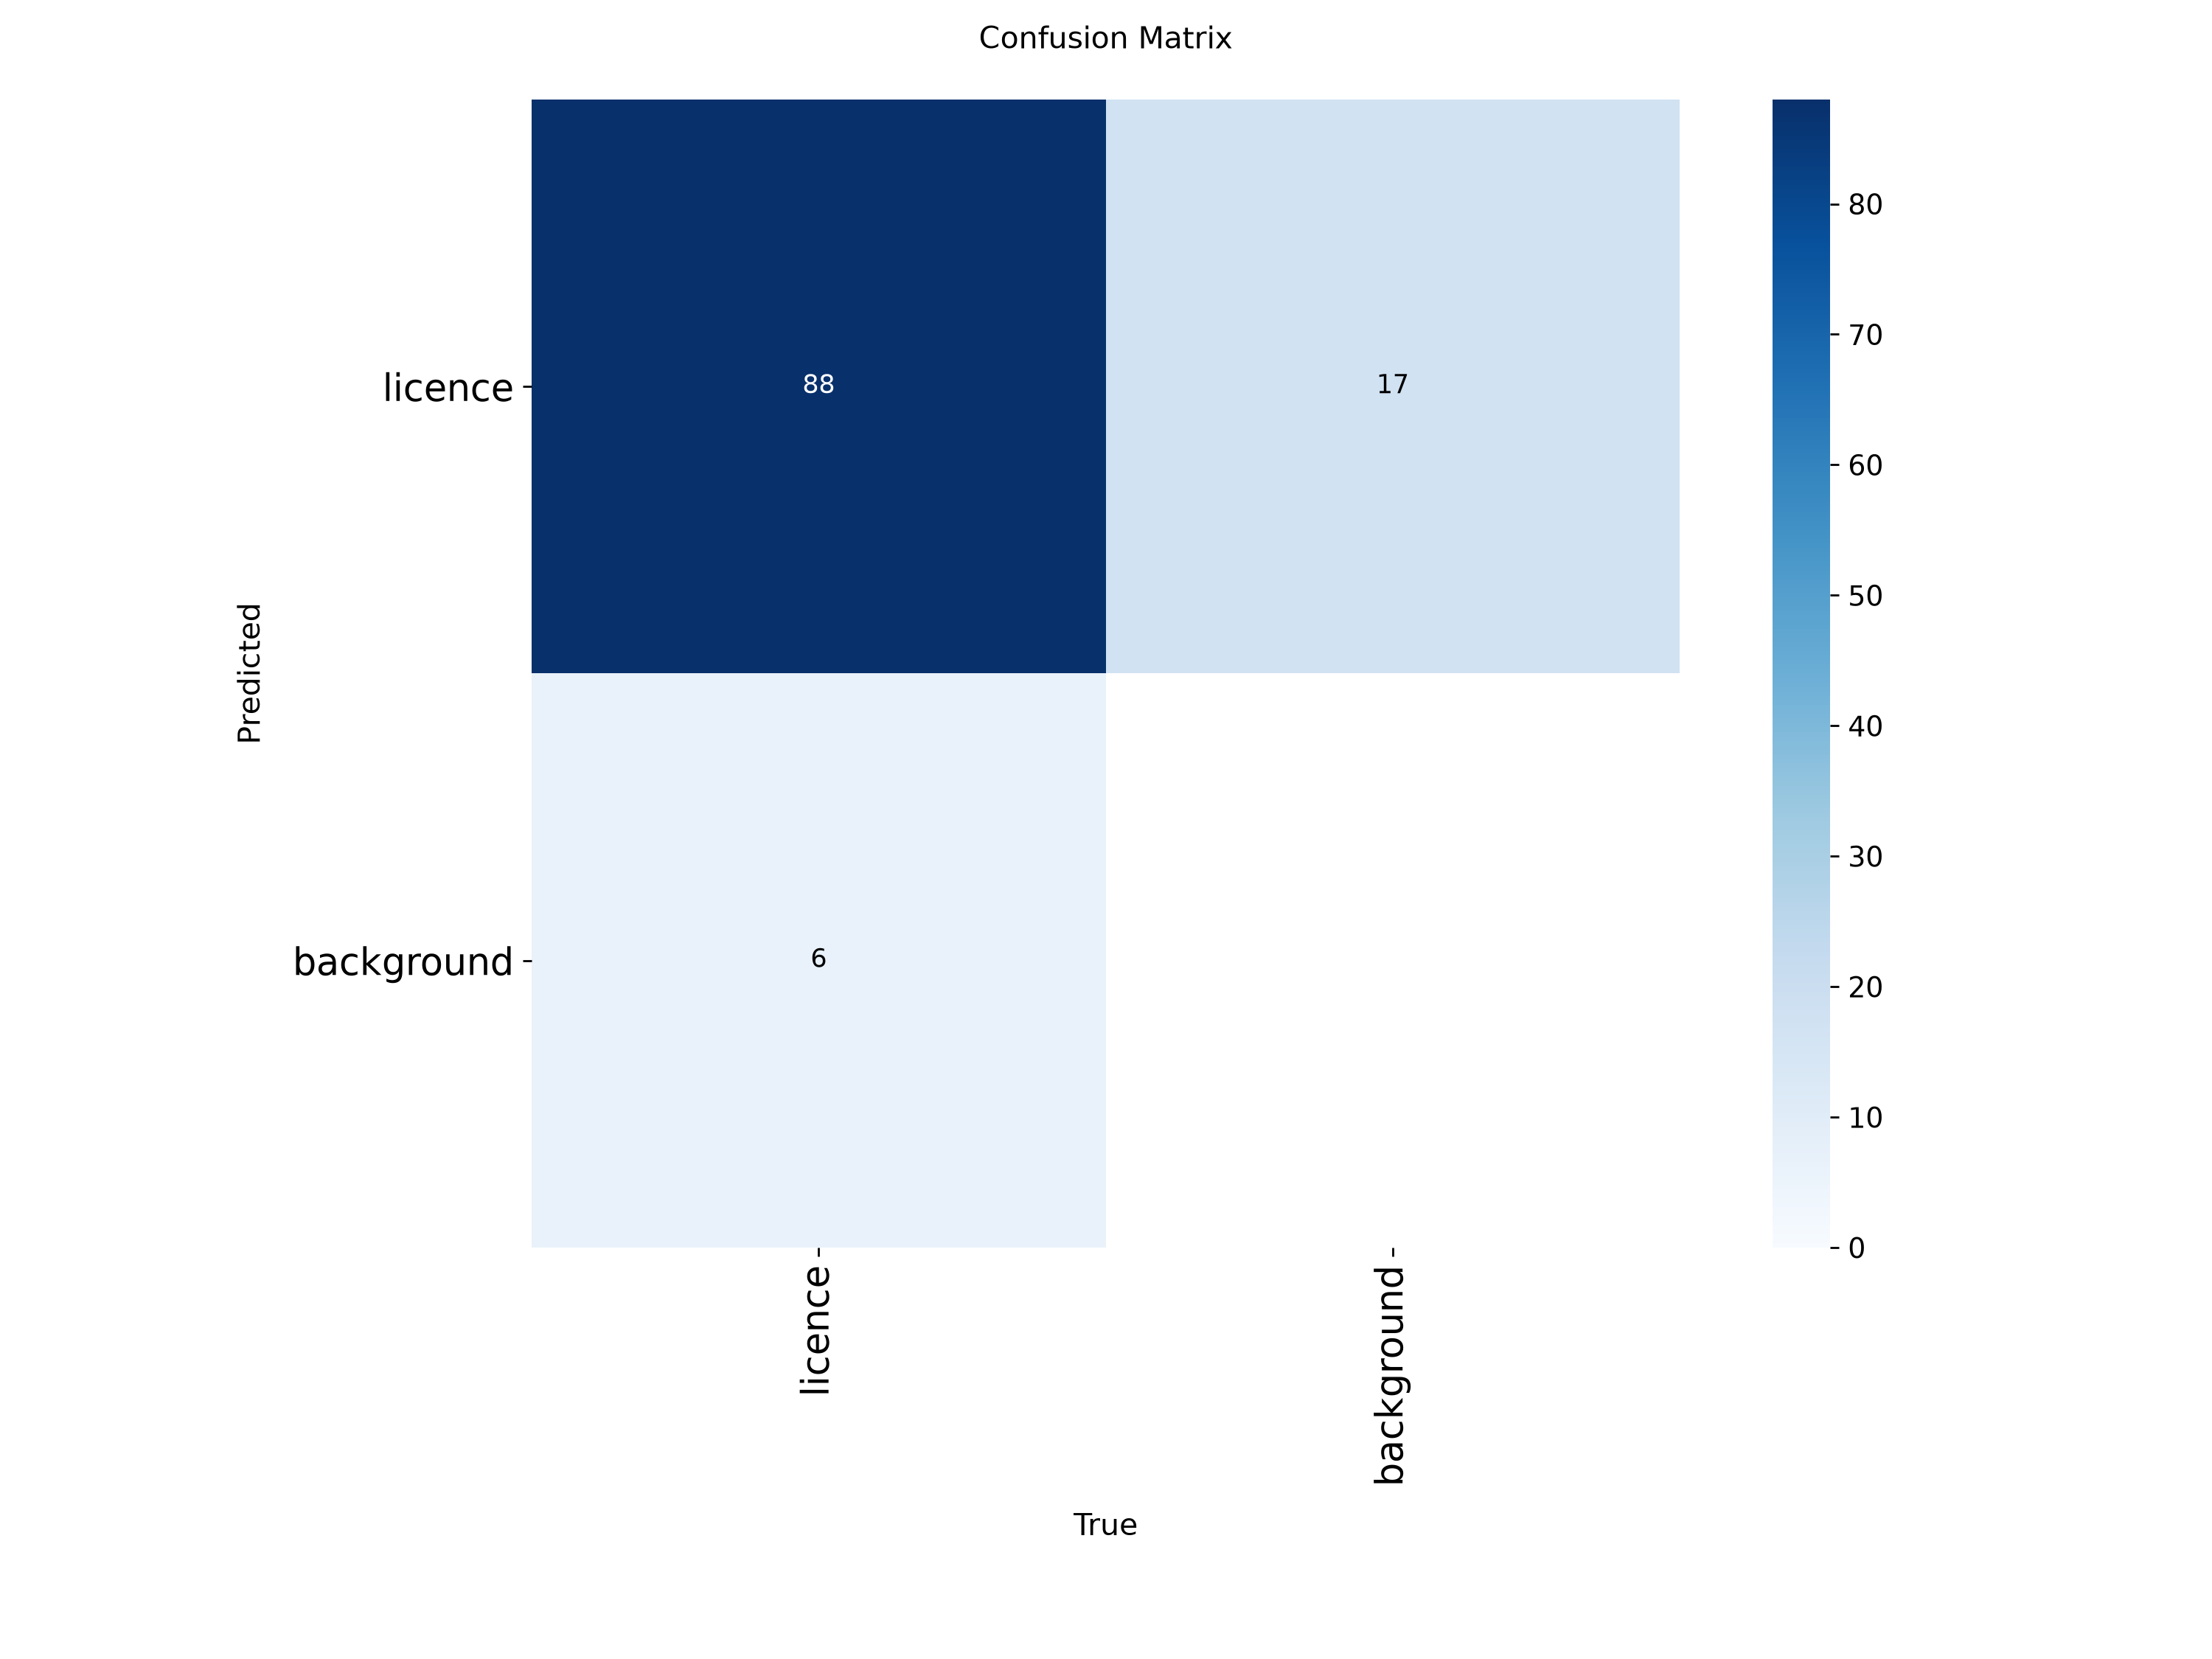

In [27]:
# 1. Gráfico Geral de Resultados (Perdas e mAP ao longo das Épocas)
print("--- Evolução do Treinamento ---")
display(Image(filename='runs/detect/yolo_placas/results.png', width=900, height=600))

# 2. Matriz de Confusão (Mostra acertos, falsos positivos e falsos negativos)
print("\n--- Matriz de Confusão ---")
display(Image(filename='runs/detect/yolo_placas/confusion_matrix.png',width=900, height=600))

In [26]:
def calcular_iou(box1, box2):
    """Calcula a Intersection over Union (IoU) entre duas caixas [xmin, ymin, xmax, ymax]."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def extrair_falsos_positivos(yolo_dataset_dir, model_path, output_dir="runs/falsos_positivos"):
        
    model = YOLO(model_path)
    os.makedirs(output_dir, exist_ok=True)
    
    img_dir = os.path.join(yolo_dataset_dir, "images", "val")
    lbl_dir = os.path.join(yolo_dataset_dir, "labels", "val")
    
    imagens = glob.glob(os.path.join(img_dir, "*.png"))
    total_fps = 0
    
    for img_path in imagens:
        nome_base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, f"{nome_base}.txt")
        
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        
        # 1. Carrega as caixas reais (Ground Truth) se existirem
        caixas_reais = []
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                linhas = f.readlines()
            for linha in linhas:
                valores = linha.strip().split()
                if len(valores) == 5:
                    x_c, y_c, wb, hb = map(float, valores[1:])
                    # Converte de YOLO (normalizado) para pixels absolutos
                    xmin = int((x_c - wb/2) * w)
                    ymin = int((y_c - hb/2) * h)
                    xmax = int((x_c + wb/2) * w)
                    ymax = int((y_c + hb/2) * h)
                    caixas_reais.append([xmin, ymin, xmax, ymax])
                    
        # 2. Executa a predição do modelo (Usando o limiar padrão de conf=0.25)
        results = model(img, conf=0.25, verbose=False)[0]
        caixas_preditas = []
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            caixas_preditas.append(([x1, y1, x2, y2], conf))
            
        # 3. Identifica Falsos Positivos
        imagem_contem_fp = False
        img_visualizacao = img.copy()
        
        for pred_box, conf in caixas_preditas:
            # Encontra o maior IoU com qualquer caixa real da imagem
            max_iou = 0
            if caixas_reais:
                max_iou = max([calcular_iou(pred_box, real_box) for real_box in caixas_reais])
            
            # Se a caixa predita não se sobrepõe minimamente com nenhuma caixa real, é Falso Positivo
            if max_iou < 0.3: 
                imagem_contem_fp = True
                total_fps += 1
                # Desenha a caixa incorreta em VERMELHO
                cv2.rectangle(img_visualizacao, (pred_box[0], pred_box[1]), (pred_box[2], pred_box[3]), (0, 0, 255), 2)
                cv2.putText(img_visualizacao, f"FP: {conf:.2f}", (pred_box[0], pred_box[1] - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
                
        # Se a imagem tiver pelo menos um Falso Positivo, desenha as reais (Verde) e salva
        if imagem_contem_fp:
            for real_box in caixas_reais:
                # Desenha a placa real em VERDE
                cv2.rectangle(img_visualizacao, (real_box[0], real_box[1]), (real_box[2], real_box[3]), (0, 255, 0), 2)
            
            # Salva o resultado na pasta de saída
            cv2.imwrite(os.path.join(output_dir, f"{nome_base}_fp.png"), img_visualizacao)
            
    print(f"Varredura concluída. Foram geradas imagens para análise em: '{output_dir}'")
    print(f"Total de predições incorretas (Falsos Positivos) isoladas: {total_fps}")

# Executa o filtro de erros
extrair_falsos_positivos(
    yolo_dataset_dir="yolo_dataset", 
    model_path="models/detector_placas.pt"
)

Varredura concluída. Foram geradas imagens para análise em: 'runs/falsos_positivos'
Total de predições incorretas (Falsos Positivos) isoladas: 18


## Fase 3: Utilizando o modelo treinado para detecção de placas

In [17]:
class ALPRPipeline:
    def __init__(self, detector_path):
        # Inicializa o detector YOLO
        self.detector = YOLO(detector_path)
        # Inicializa o EasyOCR (definido para inglês/caracteres latinos)
        # O EasyOCR baixará os pesos do modelo de OCR na primeira execução.
        self.reader = easyocr.Reader(['en'], gpu=False) # Mude gpu=True se tiver GPU disponível

    def preprocess_plate(self, plate_crop):
        """
        Aplica técnicas de OpenCV para melhorar a legibilidade da placa antes do OCR.
        """
        # 1. Converter para escala de cinza
        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        
        # 2. Redimensionar (aumentar a imagem ajuda o OCR a identificar caracteres pequenos)
        gray = cv2.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        
        # 3. Suavização para reduzir ruído
        blur = cv2.GaussianBlur(gray, (3, 3), 0)
        
        # 4. Binarização adaptativa (Otsu) para destacar os caracteres do fundo
        _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        return thresh

    def process_image(self, image_path):
        # Carrega a imagem original
        img = cv2.imread(image_path)
        if img is None:
            print("Erro ao carregar a imagem.")
            return None
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Realiza a detecção com o YOLO
        results = self.detector(img, verbose=False)[0]
        
        detections = []
        
        # Iterar sobre as caixas delimitadoras (bounding boxes) detectadas
        for box in results.boxes:
            # Coordenadas do box
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            
            # Recorta a região da placa (crop) com uma pequena margem de segurança
            h, w, _ = img.shape
            pad = 2  # pixels de margem
            crop_y1 = max(0, y1 - pad)
            crop_y2 = min(h, y2 + pad)
            crop_x1 = max(0, x1 - pad)
            crop_x2 = min(w, x2 + pad)
            
            plate_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]
            
            if plate_crop.size == 0:
                continue
                
            # Pré-processamento do recorte
            preprocessed_plate = self.preprocess_plate(plate_crop)
            
            # Executa o OCR na imagem pré-processada
            ocr_results = self.reader.readtext(preprocessed_plate)
            
            # Filtra e junta os textos detectados na placa
            plate_text = ""
            for res in ocr_results:
                # res[0]: bbox do caractere, res[1]: texto, res[2]: confiança
                text = res[1].upper().strip()
                # Remove caracteres especiais comuns que não pertencem a placas
                text = "".join([c for c in text if c.isalnum()])
                plate_text += text
                
            detections.append({
                'box': (x1, y1, x2, y2),
                'confidence': conf,
                'plate_text': plate_text,
                'crop': plate_crop,
                'preprocessed_crop': preprocessed_plate
            })
            
        return img_rgb, detections

    def plot_results(self, img_rgb, detections):
        """Plota a imagem com a caixa delimitadora e o texto reconhecido."""
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        ax = plt.gca()
        
        for det in detections:
            x1, y1, x2, y2 = det['box']
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2)
            ax.add_patch(rect)
            
            # Desenha o texto acima da caixa
            label = f"{det['plate_text']} ({det['confidence']:.2f})"
            plt.text(x1, y1 - 10, label, color='white', fontsize=12,
                     bbox=dict(facecolor='red', alpha=0.8, pad=2))
            
        plt.axis('off')
        plt.show()

Classe reinstanciada para usar OCR. COmparar com o código acima.

In [30]:
class ALPRPipelineOtimizado:
    def __init__(self, detector_path):
        self.detector = YOLO(detector_path)
        # Inicializa o EasyOCR
        self.reader = easyocr.Reader(['en'], gpu=False)

    def preprocess_plate(self, plate_crop):
        """
        Pré-processamento otimizado para o EasyOCR.
        Focamos em redimensionamento e escala de cinza para manter gradientes estruturais.
        """
        # 1. Converter para escala de cinza
        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        
        # 2. Redimensionamento de alta qualidade (INTER_CUBIC) para aumentar resolução dos caracteres
        gray = cv2.resize(gray, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
        
        # 3. Suavização leve para remover pequenos ruídos de pixel
        denoised = cv2.bilateralFilter(gray, 9, 75, 75)
        
        return denoised

    def process_image(self, image_path):
        img = cv2.imread(image_path)
        if img is None:
            print("Erro ao carregar a imagem.")
            return None
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Inferência do YOLO com limiar de confiança ajustável
        results = self.detector(img, verbose=False)[0]
        
        detections = []
        h, w, _ = img.shape
        
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            
            # --- MELHORIA: Padding Dinâmico maior para carros angulados ---
            # Adicionamos uma margem de segurança de 10% da largura/altura da placa
            box_w = x2 - x1
            box_h = y2 - y1
            pad_w = int(box_w * 0.10)
            pad_h = int(box_h * 0.10)
            
            crop_y1 = max(0, y1 - pad_h)
            crop_y2 = min(h, y2 + pad_h)
            crop_x1 = max(0, x1 - pad_w)
            crop_x2 = min(w, x2 + pad_w)
            
            plate_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]
            
            if plate_crop.size == 0:
                continue
                
            # Pré-processamento sem binarização agressiva
            preprocessed_plate = self.preprocess_plate(plate_crop)
            
            # Executa o OCR
            ocr_results = self.reader.readtext(preprocessed_plate)
            
            plate_text = ""
            for res in ocr_results:
                text = res[1].upper().strip()
                # Mantém apenas letras e números
                text = "".join([c for c in text if c.isalnum()])
                plate_text += text
                
            detections.append({
                'box': (x1, y1, x2, y2),
                'confidence': conf,
                'plate_text': plate_text,
                'crop': plate_crop,
                'preprocessed_crop': preprocessed_plate
            })
            
        return img_rgb, detections

    def plot_results(self, img_rgb, detections):
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        ax = plt.gca()
        
        for det in detections:
            x1, y1, x2, y2 = det['box']
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='green', linewidth=2)
            ax.add_patch(rect)
            
            label = f"{det['plate_text']} ({det['confidence']:.2f})"
            plt.text(x1, y1 - 10, label, color='white', fontsize=12,
                     bbox=dict(facecolor='green', alpha=0.8, pad=2))
            
        plt.axis('off')
        plt.show()

In [ ]:
class ALPRPipelineProducao:
    def __init__(self, detector_path):
        self.detector = YOLO(detector_path)
        # Inicializa o EasyOCR
        self.reader = easyocr.Reader(['en'], gpu=False)
        # Define quais caracteres são válidos para uma placa automotiva
        self.char_allowlist = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

    def preprocess_plate(self, plate_crop):
        """
        Pré-processamento avançado aplicando CLAHE para contraste adaptativo.
        Preserva as bordas das letras mesmo em ângulos difíceis ou sob sombras.
        """
        # 1. Converter para escala de cinza
        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        
        # 2. Aplicar CLAHE para equilibrar a iluminação local e destacar caracteres
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        contrast_enhanced = clahe.apply(gray)
        
        # 3. Redimensionar para garantir que o OCR identifique caracteres pequenos
        resized = cv2.resize(contrast_enhanced, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
        
        # 4. Filtro Bilateral para suavizar ruído mantendo as bordas dos caracteres nítidas
        denoised = cv2.bilateralFilter(resized, 9, 75, 75)
        
        return denoised

    def process_image(self, image_path, conf_threshold=0.25):
        img = cv2.imread(image_path)
        if img is None:
            print("Erro ao carregar a imagem.")
            return None
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        
        # Ajustar iou=0.3 força eliminação de caixas sobrepostas ---
        results = self.detector(img, conf=conf_threshold, iou=0.3, verbose=False)[0]
        
        detections = []
        h, w, _ = img.shape
        
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            
            # Adiciona margem de segurança de 10%
            box_w = x2 - x1
            box_h = y2 - y1
            pad_w = int(box_w * 0.10)
            pad_h = int(box_h * 0.10)
            
            crop_y1 = max(0, y1 - pad_h)
            crop_y2 = min(h, y2 + pad_h)
            crop_x1 = max(0, x1 - pad_w)
            crop_x2 = min(w, x2 + pad_w)
            
            plate_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]
            
            if plate_crop.size == 0:
                continue
                
            preprocessed_plate = self.preprocess_plate(plate_crop)
            
            # --- SOLUÇÃO DO OCR: Passa a allowlist de caracteres válidos ---
            ocr_results = self.reader.readtext(
                preprocessed_plate, 
                allowlist=self.char_allowlist, 
                decoder='greedy'
            )
            
            plate_text = ""
            for res in ocr_results:
                text = res[1].upper().strip()
                # Remove espaços vazios se houverem
                text = "".join([c for c in text if c != " "])
                plate_text += text
                
            detections.append({
                'box': (x1, y1, x2, y2),
                'confidence': conf,
                'plate_text': plate_text,
                'crop': plate_crop,
                'preprocessed_crop': preprocessed_plate
            })
            
        return img_rgb, detections

    def plot_results(self, img_rgb, detections):
        # Converte de RGB de volta para exibição correta se necessário
        img_to_show = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 6))
        plt.imshow(img_to_show)
        ax = plt.gca()
        
        for det in detections:
            x1, y1, x2, y2 = det['box']
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='green', linewidth=2)
            ax.add_patch(rect)
            
            label = f"{det['plate_text']} ({det['confidence']:.2f})"
            plt.text(x1, y1 - 10, label, color='white', fontsize=12,
                     bbox=dict(facecolor='green', alpha=0.8, pad=2))
            
        plt.axis('off')
        plt.show()

Using CPU. Note: This module is much faster with a GPU.


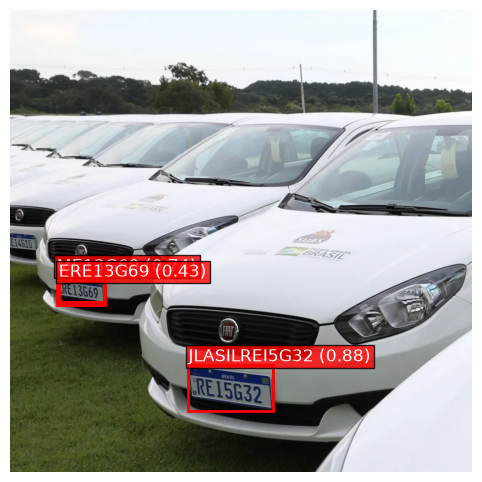

Placa 1: JLASILREI5G32 (Confiança Detector: 0.88)
Placa 2: ME13G69 (Confiança Detector: 0.74)
Placa 3: ERE13G69 (Confiança Detector: 0.43)


In [45]:
# Inicializa o pipeline com o modelo que copiamos para a pasta 'models'
pipeline = ALPRPipeline(detector_path='models/detector_placas.pt')
#pipeline = ALPRPipelineOtimizado(detector_path='models/detector_placas.pt')
#pipeline = ALPRPipelineProducao(detector_path='models/detector_placas.pt')

# Selecione um arquivo de imagem de validação para o teste
#imagem_teste = "./yolo_dataset/images/val/Cars7.png"
#imagem_teste = r"C:\Users\marcio_constancio\Downloads\nissan-leaf-2022.jpg"
imagem_teste = r"C:\Users\marcio_constancio\Downloads\placa-azul.webp"
#imagem_teste = r"C:\Users\marcio_constancio\Downloads\images.jpg"
#imagem_teste = r"C:\Users\marcio_constancio\Downloads\placa_amarela.jpg"

# Executa o pipeline
resultado = pipeline.process_image(imagem_teste)

if resultado:
    img_rgb, deteccoes = resultado
    pipeline.plot_results(img_rgb, deteccoes)
    
    # Exibe informações no console para depuração externa
    for idx, d in enumerate(deteccoes):
        print(f"Placa {idx+1}: {d['plate_text']} (Confiança Detector: {d['confidence']:.2f})")

# TESTES

In [44]:
class ALPRPipelineProducao:
    def __init__(self, detector_path):
        self.detector = YOLO(detector_path)
        # Inicializa o EasyOCR
        self.reader = easyocr.Reader(['en'], gpu=False)
        # Define quais caracteres são válidos para uma placa automotiva
        self.char_allowlist = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

    def preprocess_plate(self, plate_crop):
        """
        Pré-processamento avançado aplicando CLAHE para contraste adaptativo.
        Preserva as bordas das letras mesmo em ângulos difíceis ou sob sombras.
        """
        # 1. Converter para escala de cinza
        gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
        
        # 2. Aplicar CLAHE para equilibrar a iluminação local e destacar caracteres
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        contrast_enhanced = clahe.apply(gray)
        
        # 3. Redimensionar para garantir que o OCR identifique caracteres pequenos
        resized = cv2.resize(contrast_enhanced, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
        
        # 4. Filtro Bilateral para suavizar ruído mantendo as bordas dos caracteres nítidas
        denoised = cv2.bilateralFilter(resized, 9, 75, 75)
        
        return denoised


    def process_image(self, image_path, conf_threshold=0.25):
            img = cv2.imread(image_path)
            if img is None:
                print("Erro ao carregar a imagem.")
                return None
                
            img_rgb = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            
            # YOLO com NMS ajustado para evitar duplicações (iou=0.3)
            results = self.detector(img, conf=conf_threshold, iou=0.3, verbose=False)[0]
            
            detections = []
            h, w, _ = img.shape
            
            for box in results.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                conf = box.conf[0].item()
                
                # Margem de segurança de 10%
                box_w = x2 - x1
                box_h = y2 - y1
                pad_w = int(box_w * 0.10)
                pad_h = int(box_h * 0.10)
                
                crop_y1 = max(0, y1 - pad_h)
                crop_y2 = min(h, y2 + pad_h)
                crop_x1 = max(0, x1 - pad_w)
                crop_x2 = min(w, x2 + pad_w)
                
                plate_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]
                crop_height, crop_width, _ = plate_crop.shape
                
                if plate_crop.size == 0:
                    continue
                    
                preprocessed_plate = self.preprocess_plate(plate_crop)
                
                # Executa o OCR
                # NOTA: O EasyOCR retorna as coordenadas no tamanho da imagem passada a ele.
                # Como redimensionamos a imagem por 2.5 no preprocess_plate, as coordenadas de retorno
                # estarão na escala da imagem pré-processada.
                ocr_results = self.reader.readtext(
                    preprocessed_plate, 
                    allowlist=self.char_allowlist, 
                    decoder='greedy'
                )
                
                prep_h, prep_w = preprocessed_plate.shape[:2]
                
                valid_texts = []
                
                for res in ocr_results:
                    # O formato do retorno é: [ [[x0,y0], [x1,y1], [x2,y2], [x3,y3]], text, confidence ]
                    bbox, text, ocr_conf = res
                    
                    # Remove espaços
                    text = "".join([c for c in text.upper() if c != " "])
                    
                    # Calcula a altura da caixa de texto detectada pelo OCR
                    # Usamos os pontos y do polígono para achar a altura real
                    ys = [pt[1] for pt in bbox]
                    text_height = max(ys) - min(ys)
                    
                    # --- FILTRO 1: Altura Relativa do Texto (Ignorar letras de cidades/slogans pequenos) ---
                    # Se a altura das letras detectadas for menor que 40% da altura total da placa, ignoramos.
                    # Como a imagem foi escalada, calculamos a proporção em relação à altura da imagem pré-processada.
                    proporcao_altura = text_height / prep_h
                    
                    if proporcao_altura < 0.40:
                        continue  # Descarte de texto pequeno (ex: cidades, molduras da placa)
                    
                    # --- FILTRO 2: Tamanho Mínimo da String ---
                    # Placas têm geralmente mais de 4 caracteres. Ignora pequenos ruídos.
                    if len(text) < 4:
                        continue
                    
                    valid_texts.append((text, proporcao_altura))
                
                # Se houver mais de um bloco de texto que passou pelo filtro, 
                # priorizamos o bloco que possui a maior altura relativa (que quase certamente é a placa principal)
                if valid_texts:
                    # Ordena pelo segundo elemento da tupla (proporcao_altura) de forma decrescente
                    valid_texts.sort(key=lambda x: x[1], reverse=True)
                    plate_text = valid_texts[0][0]
                else:
                    plate_text = ""
                    
                detections.append({
                    'box': (x1, y1, x2, y2),
                    'confidence': conf,
                    'plate_text': plate_text,
                    'crop': plate_crop,
                    'preprocessed_crop': preprocessed_plate
                })
                
            return img_rgb, detections